# Example: Path tracing
This example is demonstrates how to use the path tracing functionality in echo. Path tracing is used to calculate path flows as well as add tariffs on specific paths in a network.

**Note that path tariffs are still under development, and where possible it is recommended to use port tariffs instead**

### Imports

Import everything we need.

In [7]:
import pprint
import numpy as np
np.set_printoptions(suppress=True)

In [8]:
from echo.models.base import Node, OptimisationGraph
from echo.models.agnostic import FlexPort, TellegenNode
from echo.models.electrical import ElectricalDemand, ElectricalGeneration, ElectricalStorage
from echo.configuration import Units
from echo.objectives.tariff import PathTariff
from echo.objectives.base import ObjectiveSet
from echo.optimiser import optimise
from echo.models.scenario import EngineSettings, ScenarioSettings

### Defining the scenario

The first thing we need to do is define the time periods for the optimisation. Here we have 96 time periods each 15 minutes in length.

In [9]:
time_periods = 96  # total number of intervals
interval_duration = 15  # Duration in mins of each interval
expansion_periods = 1

scenario_settings = ScenarioSettings(
    interval_duration=interval_duration,
    number_of_intervals=time_periods,
    number_of_expansion_intervals=expansion_periods,
    discount_rate=0,
)

### Build a basic BTM (Behind-the-meter) site

This example creates a simple BTM site with a load, solar and battery attached to the connection point (similar to `manual_examples/btm_battery_example.py`)

First define the load and PV generation data.

*Note:* The number of elements in the `load_array` and `pv_array` should be match the number of time periods i.e. `96`.

In [10]:
test_load = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 2.2, 2.15, 2.02, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 2.05, 2.19])

test_pv = 2 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
test_pv *= -1  # convert solar generation to negative to match convention.

Create the nodes (grid, CP, solar, load, battery) and the ports which will connect them.

In [11]:
grid = Node(node_name="grid")
grid.add_port("grid", FlexPort(units=Units.KW))

connection_point = TellegenNode(node_name="CP")
connection_point.add_ports_from_list(['load', 'battery', 'pv', 'grid'], FlexPort, units=Units.KW)  # add ports with easily referenced names

load = Node(node_name="load")
l1 = ElectricalDemand()
l1.add_demand_profile_from_array(test_load, expansion_periods)
load.ports['load'] = l1

battery = Node(node_name="battery")
b = ElectricalStorage(max_capacity=15.0,
                       depth_of_discharge_limit=0,
                       charging_power_limit=1.25,
                       discharging_power_limit=-1.25,
                       charging_efficiency=1,
                       discharging_efficiency=1,
                       initial_state_of_charge=0.0)
battery.ports['battery'] = b

solar = Node(node_name="solar")
pv = ElectricalGeneration()
pv.curtailable = False
pv.add_generation_profile_from_array(test_pv, expansion_periods)
solar.ports['pv'] = pv

Create the graph(network) by adding the nodes and joining the nodes via their ports.

In [12]:
network = OptimisationGraph()

# Populate graph with assets (nodes)
network.add_node_obj([grid, battery, load, solar, connection_point])

# Add edges to graph
network.connect_ports_and_create_edge(grid.ports['grid'], connection_point.ports['grid'])
network.connect_ports_and_create_edge(connection_point.ports['load'], load.ports['load'])
network.connect_ports_and_create_edge(connection_point.ports['battery'], battery.ports['battery'])
network.connect_ports_and_create_edge(connection_point.ports['pv'], solar.ports['pv'])

We can visualise our BTM site as a matplotlib figure. The labels are obtained from the `node_name`s. We also add some styling (through the `style` dictionary) to improve the visual appearance.

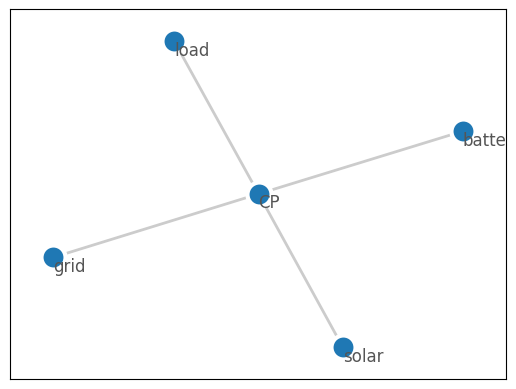

In [13]:
import matplotlib.pyplot as plt

network_figure = plt.figure()
network_axes = network_figure.add_subplot()
style = {
    "edgecolors": "#FFFFFF", # node border color
    "linewidths": 3, # node border width
    "edge_color": "#CCCCCC", # edge color of edges
    "width": 2, # edge width
    "horizontalalignment": "left", # label horizontal position
    "verticalalignment": "top", # label vertical position
    "font_color": "#555555", # label text color
}
network.draw_on_axes(axes=network_axes, with_labels=True, **style)
plt.show()

### Generate path objects

Now we have our optimisation graph, we can run a function to calculate all the paths in the graph. Paths are a list of vertices (in this case, nodes).
To create path objects, which are a class in echo, we use the `.create_path_objects()` method as shown below.

Path tracing currently ignores different commodities, it will just calculate paths based on the sources and sinks that are specified.
Source nodes are nodes we want to be considered as the start of a path, and sink nodes are nodes we want to be considered as ends of a path.

If we don't know beforehand which nodes are which, put all nodes as sources and all as sinks.
**The critical step in creating path objects is to ensure that tellegen/interconnecting nodes are NOT included as either a source or sink. This will throw an error.**

In [14]:
# Generate path objects from graph representation
network.create_path_objects(sources=[grid, battery, solar], sinks=[grid, battery, load])

/home/mike/Documents/Projects/echo/src/echo/models/base.py:944: UserWarning: Path tracing is still experimental. If you are generating paths to use path tariffs, please consider whether you can convert these tariffs to point/port tariffs.
  warnings.warn(


### Accessing path objects and applying tariffs
To access a path object, we use the `.get_path()` method. We enter the path as a list of nodes, or a list of node names.
The path object stores information like the ports along the path, the units of the flow along the path, whether we want to regularise flows.

Tariffs are applied to paths exactly the same as they are applied to ports.
A path tariff has a component, which is a path object, and a tariff array, which are the prices.

In [15]:
grid_to_battery = network.get_path([grid, connection_point, battery])

path_tariff1 = PathTariff(component=grid_to_battery,
                          tariff_array=[0.1]*48 + [0.2]*48)

grid_to_load = network.get_path([grid, connection_point, load])
path_tariff2 = PathTariff(component=grid_to_load,
                          tariff_array=[0.3]*24 + [0.1]*24 + [0.2]*48)

objective_set = ObjectiveSet(objective_list=[path_tariff1, path_tariff2])

### Setup and run the optimiser

Here we are going to use [cplex](https://www.ibm.com/products/ilog-cplex-optimization-studio/cplex-optimizer) solver.

In [16]:
engine_settings = EngineSettings(
    engine="cplex",
    engine_executable="",
    bigM=5000000,  # This value has been arbitrarily chosen
    smallM=0.0001,  # This value has been arbitrarily chosen
)

Perform the optimisation passing in all the required information (solver, scenario, network and objectives)

In [17]:
optimise_results = optimise(
    scenario_settings=scenario_settings,
    engine_settings=engine_settings,
    graph=network,
    objective_set=objective_set,
)


Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile '/tmp/tmph74f7ykk.cplex.log' open.
CPLEX> Problem '/tmp/tmp3d5i9x1x.pyomo.lp' read.
Read time = 0.02 sec. (0.17 ticks)
CPLEX> Problem name         : /tmp/tmp3d5i9x1x.pyomo.lp
Objective sense      : Minimize
Variables            :    1728  [Nneg: 672,  Box: 192,  Free: 480,
                                 Binary: 384]
Objective nonzeros   :     192
Linear constraints   :    1728  [Less: 576,  Greater: 192,  Equal: 960]
  Nonzeros           :    4895
  RHS nonzeros       :     684

Variables            : Min LB: -1.250000        Max UB: 15.00000       
Objective nonzeros   : Min   : 0.1000000   

It is easier to create poorly structured path tariffs than it is for point tariffs. By poorly structured, we mean that the combined tariffs lead to unbounded optimisation problem. This is similar to only specifying an export tariff that is greater than a corresponding import tariff at a port.

**You should always check that the optimisation has been successful when using path tariffs.**

We can do this by checking the `opt-status`.

In [18]:
print(optimise_results.opt_status)


Status: ok
User time: 3.89
Termination condition: optimal
Termination message: MIP - Integer optimal solution\x3a Objective = 1.7900000000e+01
Statistics: 
  Branch and bound: 
    Number of bounded subproblems: 179804
    Number of created subproblems: 179804
Error rc: 0
Time: 3.9556899070739746



### Anaylse the results
The flow value variable name is stored as attribute `.flow_value` on the path object.
Flow values are always positive, where a non-zero flow indicates that there is flow along the path.

In [19]:
print('Grid to battery:\n', optimise_results.values(grid_to_battery.flow_value, 0))
print('Grid to load:\n', optimise_results.values(grid_to_load.flow_value, 0))

Grid to battery:
 [1.25 0.   1.25 1.25 1.25 0.   0.   0.   1.25 0.   1.25 0.   1.25 0.
 1.25 0.   1.25 0.   1.25 0.   0.51 1.25 0.   0.   0.   0.   0.   0.
 1.06 0.   0.   0.   1.25 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
Grid to load:
 [2.13 0.84 2.3  2.11 2.2  0.98 0.95 0.9  2.02 0.94 2.19 0.94 2.12 0.9
 2.25 0.87 2.21 0.91 2.16 0.42 1.04 0.67 0.   0.   0.94 0.32 2.33 1.51
 1.57 1.32 1.91 0.   0.4  0.   1.1  0.16 0.12 0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.23 1.61 1.66 1.86 1.88 1.52 0.99 1.29 0.99 0.99 0.84 1.08 0.92 0.91
 0.72 0.91 0.96 0.93 0.76 0.91 0.94 0.86 0.92 0.88 0.8  0.94]
